# ***Building Neural Networks with PyTorch***

***Deep Learning Library, can build all sorts of neural network models and train them at scale using GPUs***

***it is similar to NumPy, except it also supports hardware acceleration and autodiff, and includes optimizers and ready-to-use neural net components***

## ***PyTorch Fundamentals***

***The core data structure of PyTorch is the tensor***

### ***PyTorch Tensors***

In [5]:
import torch

# create a tensor
x = torch.tensor([[1, 2, 7], [3, 4, 6]])
x
# contain only one data type per tensor

tensor([[1, 2, 7],
        [3, 4, 6]])

In [6]:
# shape of a tensor
x.shape

torch.Size([2, 3])

In [7]:
x.dtype

torch.int64

In [8]:
x[0, 1]

tensor(2)

In [9]:
x[:, 1]

tensor([2, 4])

***run all sorts of computations on tensors, and the API is conveniently similar to NumPy’s: for example, there’s `torch.abs()`, `torch.cos()`, `torch.exp()`, `torch.max()`, `torch.mean()`, `torch.sqrt()`, and so on. PyTorch tensors also have methods for most of these operations, so you can write `X.exp()` instead of `torch.exp(X)`***

In [10]:
10 * (x + 1.0)  # itemwise addition and multiplication 

tensor([[20., 30., 80.],
        [40., 50., 70.]])

In [11]:
x.exp()  # itemwise exponential

tensor([[   2.7183,    7.3891, 1096.6332],
        [  20.0855,   54.5981,  403.4288]])

In [12]:
x.mean  # mean of all elements

<function Tensor.mean>

In [13]:
x.max(dim=0) # max value along dimension 0 (columns)

torch.return_types.max(
values=tensor([3, 4, 7]),
indices=tensor([1, 1, 0]))

In [14]:
x@x.T  # matrix multiplication with the transpose of x

tensor([[54, 53],
        [53, 61]])

***can also convert a tensor to a NumPy array using the `numpy()` method,and create a tensor from a NumPy array***

In [15]:
import numpy as np 
x.numpy()

array([[1, 2, 7],
       [3, 4, 6]])

In [16]:
torch.tensor(np.array([[1, 2, 7], [3, 4, 6]]))

tensor([[1, 2, 7],
        [3, 4, 6]])

***Default precision for float in pytorch is 32 bits in numpy it's 64bits***

In [17]:
torch.FloatTensor([[1, 2, 7], [3, 4, 6]]) # turn the numpy array in 32bit

tensor([[1., 2., 7.],
        [3., 4., 6.]])

In [18]:
# modify a tensor in place using indexing and slicing
x[:, 1] = 0
x

tensor([[1, 0, 7],
        [3, 0, 6]])

***PyTorch’s API provides many in-place operations, such as abs_(), sqrt_(), and zero_()***

***they can sometimes save some memory and speed up your models***

In [19]:
x.relu_()  # in-place ReLU activation function
x

tensor([[1, 0, 7],
        [3, 0, 6]])

### ***Hardware Acceleration***

- ***Apple’s Metal Performance Shaders (MPS) to accelerate computations on Apple silicon such as the M1, M2, and later chips, as well as some Intel Macs with a compatible GPU***
- ***AMD Instinct accelerators and AMD Radeon GPUs, through the ROCm software stack, or via DirectML on Windows***
- ***Intel GPUs and CPUs on Linux and Windows via Intel’s oneAPI***
- ***Google TPUs via the torch_xla library***

***check this later page `539`***

### ***Autograd***

***an efficient implementation of reversemode auto-differentiation***

***Let use an example $f(x) = x^2$, differential calculus give the derivative $f(x) = 2x$ $f(5) = 25$ & $f'(x) = 10$ confirm with pytorch***

In [20]:
x = torch.tensor(5.0, requires_grad=True)  # create a tensor with gradient tracking enabled
f = x**2  # compute y = x^2
f

tensor(25., grad_fn=<PowBackward0>)

In [21]:
f.backward()  # compute the gradient of f with respect to x
x.grad  # print the gradient (df/dx)

tensor(10.)

***the `backward()` function automatically computed the gradient f'(x) at the same point x = 5.0***

- ***First create a tensor x equal to 5 & told pytorch it's a variable not constant by specifying `requires_grad=True`. Knowing this pytorch will keep track of operations involving x, as this is needed to create the computational graph in order to do `backprop` on it & get derivative of f regard to x. In this graph tensor x is `leaf node`***
- ***compute f = x\*\*2, result a tensor = 25, f also carries `grad_fn` attribute which represent the operation that created the tensor `(**, power, hence the name PowBackward0)` which tells PyTorch how to backpropagate the gradients through this particular operation. `grad_fn` is the attribute how pytorch keep track of the comp graph***
- ***Next call `f.backward()`: this backpropagates the gradients through the computation graph, starting with `f`, and all the way back to the `leaf nodes` (just x in this case)***
- ***Lastly, we can just read the x tensor’s grad attribute, which was computed during backprop this gives us the derivative of `f` with regard to `x`***

***PyTorch creates a new computation graph on the fly during each forward pass, as the operations are executed. This allows PyTorch to support very dynamic models containing loops and conditionals***


>***Gradient tells "if i change this parameter how much the loss will change". $\partial Loss / \partial Weight$ ~ this is called gradient of loss w.r.t weight***

>***Backprop compute the gradient but don't update the parameter***
`loss.backward()` ~ *this run backprop & fills* `weight.grad` *with gradients*

>***Gradient descent uses those gradients to update weights*** $w_{new}=w_{old}-\eta \frac {\partial L}{\partial w}$ `optimizer.step()`

***Running gradient descent will push $x$ toward 0, since that’s the value that minimizes f(x) = x2. To do GD step need to disable `gradient tracking` can be done by placing GD step inside a `torch.no_grad()` context***

>***The computation graph is meant to represent the forward computation of the model not the optimization algo***

In [22]:
learning_rate = 0.1
with torch.no_grad():
    x -= learning_rate * x.grad  # update x using gradient descent

***Another way to avoid gradient computation is to use the variable’s detach() method: this creates a new tensor detached from the computation graph, with `requires_grad=False`, but still pointing to the same data in memory.***

In [23]:
x_detached = x.detach()  # create a new tensor that shares the same data but does not track gradients
x_detached -= learning_rate * x.grad   # modifying x_detached is same as modifying x, but it does not affect the gradient tracking of x

***Before repeating the whole process it's essencial to zero out the gradient of all model parameter***

In [24]:
x.grad.zero_()  # reset the gradient to zero for the next iteration

tensor(0.)

***Whole training loop***

In [25]:
learning_rate = 0.1
x = torch.tensor(5.0, requires_grad=True)
for iteration in range(100):
    f = x**2
    f.backward()
    with torch.no_grad():
        x -= learning_rate * x.grad
        x.grad.zero_()

***In-place operation create runtime error in autograd, `they can replace the values autograd still needs to compute gradients`***

In [26]:
t = torch.tensor(2.0, requires_grad=True) 
z = t.exp()  # this is an intermediate result 
# z += 1  # this is an in-place operation 
z.backward()  #   RuntimeError! 

***z is calculated but z.backward() throws an error as “one of the variables needed for gradient computation has been modified by an in-place operation”. result of `z = t.exp()` was lost when ran `z+=1` so when backward pass reached the `exp` operation gradient couldn't be computed***

***replace `z+=1` wiht `z = z + 1` a new tensor is created and assigned to the same variable, but the original tensor is unchanged and recorded in the computation graph of the final tensor***

- ***Some operations—such as exp(), relu(), rsqrt(), sigmoid(), sqrt(), tan(), and tanh()—save their outputs in the computation graph during the forward pass, then use these outputs to compute the gradients during the backward pass. 5 This means that you must not modify such an operation’s output in place, or you will get an error during the backward pass***
- ***Other operations—such as abs(), cos(), log(), sin(), square(), and var()—save their inputs instead of their output. 6 Such an operation doesn’t care if you modify its output in place, but you must not modify its inputs in place before the backward pass***
- ***Some operations—such as max(), min(), norm(), prod(), sgn(), and std()—save both the inputs and the outputs, so you must not modify either of them in place before the backward pass***
- ***a few operations—such as ceil(), floor(), mean(), round(), and sum()—save neither their inputs nor their outputs. 7 You can safely modify them in place***

## ***Implementing Linear Regression***

### ***Linear Regression Using Tensors and Autograd***

In [27]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(*fetch_california_housing(return_X_y=True), random_state=42)

x_valid, x_test, y_valid, y_test = train_test_split(x_test, y_test, random_state=42)

***Normalize using tensor operations***

In [28]:
x_train = torch.FloatTensor(x_train) # convert the training data to a PyTorch tensor of type float
x_valid = torch.FloatTensor(x_valid)
x_test = torch.FloatTensor(x_test)
means = x_train.mean(dim=0, keepdim=True) # mean of each column (feature) in the training data
stds = x_train.std(dim=0, keepdim=True) # standard deviation of each column (feature) in the training data
# keepdim=True keeps the dimensions of the result the same as the input, so that we can easily broadcast it when standardizing the data
x_train = (x_train - means) / stds # standardize the training data
x_valid = (x_valid - means) / stds
x_test = (x_test - means) / stds

***also convert the targets to tensors. Since our predictions will be column vectors (matrices with a single column), we need to ensure that our targets are also column vectors. Unfortunately, the NumPy arrays representing the targets are one-dimensional, so we need to reshape the tensors to column vectors by adding a second dimension of size 1***

In [29]:
y_train = torch.FloatTensor(y_train).reshape(-1, 1) 
y_valid = torch.FloatTensor(y_valid).reshape(-1, 1) 
y_test = torch.FloatTensor(y_test).reshape(-1, 1) 

***data is ready now create parameter for our  linear regression model***

***Weights are initialized randomly & bias is initialized with 0***

In [30]:
torch.manual_seed(42)  # withoud seed give different random number in different run
n_features = x_train.shape[1]  # there are 8 input features 
w = torch.randn((n_features, 1), requires_grad=True) 
b = torch.tensor(0., requires_grad=True) 

***Now train the model using autodiff to compute the gradient. Use Batch GD***

In [31]:
learning_rate = 0.4
n_epochs = 20
for epoch in range(n_epochs):
    y_pred = x_train @ w + b
    loss = ((y_pred -y_train)**2).mean()
    loss.backward()
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
        w.grad.zero_()
        b.grad.zero_()
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}')

Epoch 1/20, Loss: 16.0134
Epoch 2/20, Loss: 4.6758
Epoch 3/20, Loss: 2.1239
Epoch 4/20, Loss: 1.2568
Epoch 5/20, Loss: 0.9282
Epoch 6/20, Loss: 0.7924
Epoch 7/20, Loss: 0.7286
Epoch 8/20, Loss: 0.6932
Epoch 9/20, Loss: 0.6697
Epoch 10/20, Loss: 0.6518
Epoch 11/20, Loss: 0.6371
Epoch 12/20, Loss: 0.6244
Epoch 13/20, Loss: 0.6134
Epoch 14/20, Loss: 0.6036
Epoch 15/20, Loss: 0.5950
Epoch 16/20, Loss: 0.5873
Epoch 17/20, Loss: 0.5805
Epoch 18/20, Loss: 0.5744
Epoch 19/20, Loss: 0.5690
Epoch 20/20, Loss: 0.5641


***Make prediction***

***x_new must be PyTorch tensor***

In [32]:
x_new = x_test[:3]
with torch.no_grad():
    y_pred = x_new @ w + b

y_pred 

tensor([[2.2657],
        [2.8828],
        [1.0302]])

### ***Linear Regression Using PyTorch’s High-Level API***

***nn.Linear class one of the module, subclass of nn.Module class***

***for most neural networks you will need to assemble many modules***

***nn.Linear module contains a bias vector (with one bias term per neuron), and a weight matrix (with one row per neuron and one column per input dimension, which is the transpose of the weight matrix)***

In [33]:
import torch.nn as nn

torch.manual_seed(42) 
model = nn.Linear(in_features=n_features, out_features=1)  # create a linear layer with n_features input features and 1 output feature

In [34]:
model.bias

Parameter containing:
tensor([0.3117], requires_grad=True)

In [35]:
model.weight

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)

***both parameters were automatically initialized randomly (which is why we used `manual_seed()` to get reproducible results).These parameters are instances of the torch.nn.Parameter class, which is a subclass of the tensor.Tensor class: this means that you can use them exactly like normal tensors***

***A module’s `parameters() method` returns an iterator over all of the module’s attributes of type Parameter, as well as all the parameters of all its submodules, recursively (if it has any). It does not return regular tensors, even those with `requires_grad=True`. That’s the main difference between a regular tensor and a Parameter***

In [36]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
Parameter containing:
tensor([0.3117], requires_grad=True)


***`named_parameters()` method that returns an iterator over pairs of parameter names and values***

***A module can be called just like a regular function***

***let’s make some predictions for the first two instances in the training set (since the model is not trained yet, its parameters are random and the predictions are terrible)*** 

***Reread or watch this part ...***

In [37]:
model(x_train[:2])

tensor([[0.8036],
        [0.4508]], grad_fn=<AddmmBackward0>)

***When we use a module as a function, PyTorch internally calls the module’s `forward() method`***

***in `nn.Linear` model the `forward()` method compute `X @ self.weight.T + self.bias` that's just what we need for liner regression***

***Notice the result contains the `grad_fn` attribute, showing that autograd did its job and tracked the computation graph while the model was making its predictions***

***Now we have the model, we need to create an optimizer to update model parameters & choose a loss function***

In [38]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  # create an optimizer that will update the parameters of the model using stochastic gradient descent
mse = nn.MSELoss()  # create a mean squared error loss function

***created an instance of `nn.MSELoss` class, this is also a module so can use as a function***

***create a function to train model***

In [39]:
def train_bgd(model, optimizer, criterion, x_train, y_train, n_epochs):
    for epoch in range(n_epochs):
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}')

***In this func using high-level constructors rather than working directly with the tensor & autograd***

- ***the loss function object is commonly referred to as the criterion, to distinguish it from the loss value itself (which is computed at each training iteration using the criterion). In this example, it’s the `MSELoss instance`***
- ***`optimizer.step()` line corresponds to the two lines that updated `b` and `w`***
- ***`optimizer.zero_grad()` line corresponds to the two lines that zeroed out `b.grad` and `w.grad`***

***Call the function to train the model***

In [40]:
train_bgd(model, optimizer, mse, x_train, y_train, n_epochs)

Epoch 1/20, Loss: 4.2796
Epoch 2/20, Loss: 0.7742
Epoch 3/20, Loss: 0.6209
Epoch 4/20, Loss: 0.6018
Epoch 5/20, Loss: 0.5914
Epoch 6/20, Loss: 0.5830
Epoch 7/20, Loss: 0.5759
Epoch 8/20, Loss: 0.5697
Epoch 9/20, Loss: 0.5642
Epoch 10/20, Loss: 0.5594
Epoch 11/20, Loss: 0.5552
Epoch 12/20, Loss: 0.5514
Epoch 13/20, Loss: 0.5481
Epoch 14/20, Loss: 0.5451
Epoch 15/20, Loss: 0.5425
Epoch 16/20, Loss: 0.5402
Epoch 17/20, Loss: 0.5381
Epoch 18/20, Loss: 0.5363
Epoch 19/20, Loss: 0.5347
Epoch 20/20, Loss: 0.5332


In [41]:
x_new = x_test[:3]
with torch.no_grad():
    y_pred = model(x_new)

y_pred

tensor([[2.3269],
        [2.9327],
        [1.0614]])

***these predictions are different from the previous as the `nn.Linear module` initializes the parameters slightly differently, t uses a uniform random distribution from − √2 \4 to + √2/4  for both the weights and the bias term***

## ***Implementing a Regression MLP***

***PyTorch provides `nn.Sequential` module that chains multiple modules: when call this module with some i/p, it feeds these i/p to the first module, then feeds the o/p of the first module to the second module, and so on***

***Most neural networks contain stacks of modules, and in fact many neural networks are just one big stack of modules***

***Build a MLP with 2 hidden layer & 1 output layer***

In [42]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50), # hidden layer 1 (8, 50)
    nn.ReLU(),
    nn.Linear(50, 40), # hidden layer 2
    nn.ReLU(),
    nn.Linear(40, 1) # output layer 
)

- ***The first layer must have the right number of inputs for our data: `n_features`*** 
- ***number of outputs must match the targets’ dimensionality***

***Train the model now***

In [43]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
train_bgd(model, optimizer, mse, x_train, y_train, n_epochs)

Epoch 1/20, Loss: 4.9947
Epoch 2/20, Loss: 2.0734
Epoch 3/20, Loss: 1.0232
Epoch 4/20, Loss: 0.8790
Epoch 5/20, Loss: 0.7960
Epoch 6/20, Loss: 0.7444
Epoch 7/20, Loss: 0.7114
Epoch 8/20, Loss: 0.6894
Epoch 9/20, Loss: 0.6740
Epoch 10/20, Loss: 0.6625
Epoch 11/20, Loss: 0.6534
Epoch 12/20, Loss: 0.6456
Epoch 13/20, Loss: 0.6387
Epoch 14/20, Loss: 0.6323
Epoch 15/20, Loss: 0.6264
Epoch 16/20, Loss: 0.6207
Epoch 17/20, Loss: 0.6152
Epoch 18/20, Loss: 0.6100
Epoch 19/20, Loss: 0.6049
Epoch 20/20, Loss: 0.6000


***we are still using batch gradient descent, `computing the gradients over the entire training set at each iteration`datasets and large models, we need to switch to mini-batch gradient descent***

***This works with small datasets, but if we want to be able to scale up to large datasets and large models, we need to switch to mini-batch gradient descent***

## ***Implementing Mini-Batch Gradient Descent Using DataLoaders***

***To implement mini-batch GD PyTorch provides a class named `DataLoader` in the `torch.utils.data` module***

***It can efficiently load batches of data of the desired size, and shuffle the data at each epoch if we want***

***`DataLoader` expects the dataset to be represented as an object with at least two methods: `__len__(self)` to get the number of samples in the dataset, and `__getitem__(self, index)` to load the sample at the given index `(including the target)`***

***Here training data are available at `x_train` & `y_train` tensor so we need to wrap these tensors in a dataset object with `TensorDataset` class. DataLoader pull batches from this dataset, also want the dataset to shuffle so specify `shuffle=True`***

In [44]:
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # create a data loader that will load the training data in batches of 64 and shuffle the data at each epoch

> ***Now that we have a larger model and we have the tools to train it one batch at a time, it’s a good time to start using hardware acceleration. It’s really quite simple: we just need to move the model to the GPU, which will move all of its parameters to the GPU RAM, and then at the start of each iteration during training we must copy each batch to the GPU. To move the model, we can just use its `to()` method, just like we did with tensors:***

In [45]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50),  # hidden layer with 30 neurons
    nn.ReLU(),  
    nn.Linear(50, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)
model = model.to('cpu')  # move the model to the GPU if available

***can also create the loss function and optimizer (but using a lower learning rate, such as 0.02)***

***create a train() function to implement minibatch GD***

In [46]:
def train(model, optimizer, criterion, train_loader, n_epochs):
    model .train()  # set the model to training mode
    for epoch in range(n_epochs):
        total_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to('cpu'), y_batch.to('cpu') # use cuda if available `"cuda" if torch.cuda.is_available() else "cpu"`
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mse = total_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {mse:.4f}')


***At every epoch, the function iterates through the whole training set, one batch at a time***

***`model.train` -> switches the model and all of its submodules to training mode. it will be important when start using layers that behave differently during training and evaluation `(e.g., nn.Dropout or nn.BatchNorm1d)`. Whenever want to use the model outside of training `(evaluation, or make predictions on new instances)`, you must first switch the model to evaluation mode by running `model.eval()`***

***that `model.training` holds a boolean that indicates the current mode***

***call this train() function to train our model on the GPU***

In [47]:
train(model, optimizer, mse, train_loader, n_epochs)

Epoch [1/20], Loss: 4.9950
Epoch [2/20], Loss: 4.9944
Epoch [3/20], Loss: 4.9941
Epoch [4/20], Loss: 4.9942
Epoch [5/20], Loss: 4.9949
Epoch [6/20], Loss: 4.9949
Epoch [7/20], Loss: 4.9948
Epoch [8/20], Loss: 4.9953
Epoch [9/20], Loss: 4.9945
Epoch [10/20], Loss: 4.9955
Epoch [11/20], Loss: 4.9949
Epoch [12/20], Loss: 4.9963
Epoch [13/20], Loss: 4.9939
Epoch [14/20], Loss: 4.9950
Epoch [15/20], Loss: 4.9959
Epoch [16/20], Loss: 4.9945
Epoch [17/20], Loss: 4.9951
Epoch [18/20], Loss: 4.9950
Epoch [19/20], Loss: 4.9946
Epoch [20/20], Loss: 4.9951


***Page 563 ...***

## ***Model Evaluation***

***Function takes the `model` and a `DataLoader` for the dataset that we want to evaluate the model on, as well as a function to compute the metric for a given batch, and lastly a function to `aggregate the batch metrics`***

In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [49]:
def evaluate(model, data_loader, metric_fn, agggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model(x_batch)
            metric = metric_fn(y_pred, y_batch)
            metrics.append(metric.item())
    return agggregate_fn(torch.tensor(metrics))

***Now let’s build a `TensorDataset` and a `DataLoader` for our validation set, and pass it to our `evaluate()` function to compute the validation MSE***

In [50]:
valid_dataset = TensorDataset(x_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32)
valid_mse = evaluate(model, valid_loader, mse)
valid_mse

tensor(4.8527)

***RMSE [PyTorch doesn't have that]***

In [51]:
def rmse(y_pred, y_true):
    return ((y_pred - y_true)**2).mean().sqrt()

In [52]:
evaluate(model, valid_loader, rmse)

tensor(2.1901)

***The RMSE should be equal to the sqrt of the MSE; however, when compute the sqrt of the MSE that we found earlier, we get a different result*** 

In [53]:
valid_mse.sqrt()

tensor(2.2029)

***cause instead of calculating the RMSE over the whole validation set, we computed it over each batch and then computed the mean of all these batch RMSEs.To solve this, we can use the MSE as our `metric_fn`, and use the `aggregate_fn` to compute the square root of the mean MSE***

In [54]:
evaluate(model, valid_loader, mse, agggregate_fn=lambda metrics:torch.sqrt(torch.mean(metrics)))

tensor(2.2029)

***Rather than implement metrics yourself, you may prefer to use the TorchMetrics library***

***which provides many well-tested `streaming metrics`. A streaming metric is an object that keeps track of a given metric, and can be updated one batch at a time***

In [55]:
!pip install torchmetrics torchvision


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import torchmetrics
def evaluate_tm(model,data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric state before evaluation
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(x_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

***Then we can create an RMSE streaming metric, move it to the GPU, and use it to evaluate the validation set***

In [57]:
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)  # create a torchmetrics RMSE metric
evaluate_tm(model, valid_loader, rmse)

tensor(2.2028)

***We get the correct result***

***try updating the `train()` function to evaluate your model’s performance during training, both on the training set `(during each epoch)` and on the validation set `(at the end of each epoch)`. if the performance on the training set is much better than on the validation set, your model is probably overfitting the training set, or there is a bug, such as a data mismatch between the training set and the validation set***

***Can be detected by analyzing the `learning curve`***

***so far we have only looked at simple sequential models, composed of a sequence of linear layers and ReLU activation functions. How would you build a more complex, nonsequential model?***

In [59]:
import matplotlib.pyplot as plt

Epoch 1/20, train loss: 0.7414, train metric: 0.8611, valid metric: 0.7088
Epoch 2/20, train loss: 0.4650, train metric: 0.6820, valid metric: 0.6616
Epoch 3/20, train loss: 0.4224, train metric: 0.6500, valid metric: 0.6418
Epoch 4/20, train loss: 0.4033, train metric: 0.6351, valid metric: 0.6300
Epoch 5/20, train loss: 0.3903, train metric: 0.6247, valid metric: 0.6164
Epoch 6/20, train loss: 0.3775, train metric: 0.6145, valid metric: 0.6226
Epoch 7/20, train loss: 0.3699, train metric: 0.6082, valid metric: 0.6127
Epoch 8/20, train loss: 0.3632, train metric: 0.6026, valid metric: 0.6320
Epoch 9/20, train loss: 0.3576, train metric: 0.5981, valid metric: 0.5948
Epoch 10/20, train loss: 0.3515, train metric: 0.5930, valid metric: 0.5963
Epoch 11/20, train loss: 0.3481, train metric: 0.5901, valid metric: 0.5914
Epoch 12/20, train loss: 0.3420, train metric: 0.5848, valid metric: 0.5898
Epoch 13/20, train loss: 0.3374, train metric: 0.5809, valid metric: 0.5862
Epoch 14/20, train lo

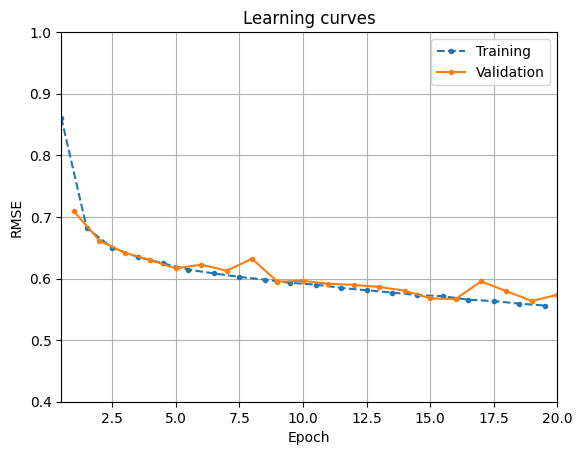

In [60]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 30), nn.ReLU(),
    nn.Linear(30, 1)
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader,
                 n_epochs)

# Since we compute the training metric
plt.plot(np.arange(n_epochs) + 0.5, history["train_metrics"], ".--",
         label="Training")
plt.plot(np.arange(n_epochs) + 1.0, history["valid_metrics"], ".-",
         label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.grid()
plt.title("Learning curves")
plt.axis([0.5, 20, 0.4, 1.0])
plt.legend()
plt.show()

## ***Building Nonsequential Models Using Custom Modules***

***One example of a nonsequential neural network is a Wide & Deep neural network***

***It connects all or part of the inputs directly to the output layer***

***This architecture makes it possible for the neural network to learn both deep patterns (using the deep path) and simple rules (through the short path)***

***The short path can also be used to provide manually engineered features to the neural network***

***In regular MLP all the data flows through full layer, so simple patterns may distort by the sequence of transform***

***Build a neural network...***

***Because this wide and deep architecture is nonsequential, we have to create a custom module***

***just create a class derived from `torch.nn.Module` then create all the layers needed in the constructor (`after calling the base class __init__() method`), & define how these layers shou;d be sued by the method `forward()` method***

In [61]:
class WideandDeep(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features, 50), 
            nn.ReLU(),
            nn.Linear(50, 40), 
            nn.ReLU(),
        )
        self.output_layer = nn.Linear(40 + n_features, 1)  # the output layer takes the output of the deep stack and the original input features as input
    
    def forward(self, x):
        deep_output = self.deep_stack(x)
        wide_and_deep = torch.concat([x, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

***Notice! we can use any kind of module inside our custom module, `nn.sequential` for the deeper part of the layer***

***seperated the output layer as need to feed it the concatination of the model's i/p & deeper part's o/p, for this reason the `output_layer` has `40+n_features` i/p***

***In the `forward()` method, just feed the input `X` to the deep stack, concatenate the input and the deep stack’s output, and feed the result to the output layer***

***Now create an instance of our custom module, move it to the GPU, train it, evaluate it, and use it exactly like our previous models***

In [62]:
torch.manual_seed(42)
model = WideandDeep(n_features).to(device)
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train(model, optimizer, mse, train_loader, n_epochs)    

Epoch [1/20], Loss: 1.2417
Epoch [2/20], Loss: 0.6135
Epoch [3/20], Loss: 0.5668
Epoch [4/20], Loss: 0.5361
Epoch [5/20], Loss: 0.5145
Epoch [6/20], Loss: 0.4998
Epoch [7/20], Loss: 0.4874
Epoch [8/20], Loss: 0.4783
Epoch [9/20], Loss: 0.4696
Epoch [10/20], Loss: 0.4641
Epoch [11/20], Loss: 0.4556
Epoch [12/20], Loss: 0.4503
Epoch [13/20], Loss: 0.4448
Epoch [14/20], Loss: 0.4395
Epoch [15/20], Loss: 0.4344
Epoch [16/20], Loss: 0.4301
Epoch [17/20], Loss: 0.4254
Epoch [18/20], Loss: 0.4215
Epoch [19/20], Loss: 0.4176
Epoch [20/20], Loss: 0.4137


***what if you want to send a subset of the features through the wide path and a different subset `(possibly overlapping)` through the deep path***

***one approach is to split the inputs inside the `forward()` method***

![handling multiple input.png](<attachment:handling multiple input.png>)
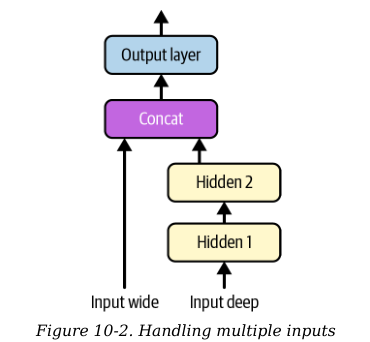

In [63]:
class WideandDeepV2(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features, 50),
            nn.ReLU(),
            nn.Linear(50, 40),
            nn.ReLU()
        )
        self.output_layer = nn.Linear(40 + n_features, 1)

    def forward(self, x):
        x_wide = x[:, :5]
        x_deep = x[:, 2:]
        deep_output = self.deep_stack(x_deep)
        wide_and_deep = torch.concat([x_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

***This works fine; however, in many cases it’s preferable to just let the model take two separate tensors as input***

In [64]:
torch.manual_seed(42)
model = WideandDeep(n_features).to(device)
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train(model, optimizer, mse, train_loader, n_epochs)    

Epoch [1/20], Loss: 1.2417
Epoch [2/20], Loss: 0.6135
Epoch [3/20], Loss: 0.5668
Epoch [4/20], Loss: 0.5361
Epoch [5/20], Loss: 0.5145
Epoch [6/20], Loss: 0.4998
Epoch [7/20], Loss: 0.4874
Epoch [8/20], Loss: 0.4783
Epoch [9/20], Loss: 0.4696
Epoch [10/20], Loss: 0.4641
Epoch [11/20], Loss: 0.4556
Epoch [12/20], Loss: 0.4503
Epoch [13/20], Loss: 0.4448
Epoch [14/20], Loss: 0.4395
Epoch [15/20], Loss: 0.4344
Epoch [16/20], Loss: 0.4301
Epoch [17/20], Loss: 0.4254
Epoch [18/20], Loss: 0.4215
Epoch [19/20], Loss: 0.4176
Epoch [20/20], Loss: 0.4137


### ***Building Models with Multiple Inputs***

***Some models require multiple inputs that cannot easily be combined into a single tensor***

***For example, the inputs may have a different number of dimensions `(e.g., when you want to feed both images and text to the neural network)`***

***To make the WideAndDeep model take 2 seperate i/p we must change the model's `forward()` method***

In [65]:
class WideAndDeepv3(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features, 50),
            nn.ReLU(),
            nn.Linear(50, 40),
            nn.ReLU()
        )
        self.output_layer = nn.Linear(40 + n_features, 1)

    def forward(self, x_wide, x_deep):
        deep_output = self.deep_stack(x_deep)
        wide_and_deep = torch.concat([x_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)


***Next, we need to create datasets that return the wide and deep inputs separately***

In [66]:
torch.manual_seed(42)
train_data_wd = TensorDataset(x_train[:, :5], x_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)

valid_data_wd = TensorDataset(x_valid[:, :5], x_valid[:, 2:], y_valid)
valid_loader_wd = DataLoader(valid_data_wd, batch_size=32)

test_data_wd = TensorDataset(x_test[:, :5], x_test[:, 2:], y_test)
test_loader_wd = DataLoader(test_data_wd, batch_size=32)

***Since data loaders now return three tensors instead of two at each iteration, we need to update the main loop in the evaluation and training functions***

In [67]:
def evaluate_multi_input(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for x_batch_wide, x_batch_deep, y_batch in data_loader:
            x_batch_wide = x_batch_wide.to(device)
            x_batch_deep = x_batch_deep.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(x_batch_wide, x_batch_deep)
            metric.update(y_pred, y_batch)
    return metric.compute()

***Alternatively, since the order of the inputs matches the order of the `forward()` method’s arguments, we can use Python’s `* operator` to unpack all the inputs returned by the `data_loader` and pass them to the model***

***advantage of this implementation is that it will work with models that take any number of inputs, not just two, as long as the order is correct***

In [68]:
def train_multi_input(model, optimizer, criterion,metric, train_loader, valid_loader, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        metric.reset()
        for *X_batch_inputs, y_batch in train_loader:
            model.train()
            X_batch_inputs = [X.to(device) for X in X_batch_inputs]
            y_batch = y_batch.to(device)
            y_pred = model(*X_batch_inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        return metric.compute()

torch.manual_seed(42)
model = WideandDeep(n_features).to(device)
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train(model, optimizer, mse, train_loader, n_epochs)    

Epoch [1/20], Loss: 1.2417
Epoch [2/20], Loss: 0.6135
Epoch [3/20], Loss: 0.5668
Epoch [4/20], Loss: 0.5361
Epoch [5/20], Loss: 0.5145
Epoch [6/20], Loss: 0.4998
Epoch [7/20], Loss: 0.4874
Epoch [8/20], Loss: 0.4783
Epoch [9/20], Loss: 0.4696
Epoch [10/20], Loss: 0.4641
Epoch [11/20], Loss: 0.4556
Epoch [12/20], Loss: 0.4503
Epoch [13/20], Loss: 0.4448
Epoch [14/20], Loss: 0.4395
Epoch [15/20], Loss: 0.4344
Epoch [16/20], Loss: 0.4301
Epoch [17/20], Loss: 0.4254
Epoch [18/20], Loss: 0.4215
Epoch [19/20], Loss: 0.4176
Epoch [20/20], Loss: 0.4137


***advantage of this implementation is that it will work with models that take any number of inputs, not just two, as long as the order is correct***

***When your model has many `inputs`, it’s easy to make a mistake and mix up the `order` of the inputs***

***To avoid this, it can be a good idea to name each `input`. For this, you can define a `custom dataset` that returns a `dictionary` from `input names` to `input values`***

In [69]:
class WideAndDeepDataset(torch.utils.data.Dataset):
    def __init__(self, x_wide, x_deep, y):
        self.x_wide = x_wide
        self.x_deep = x_deep
        self.y = y

    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        input_dict = {"x_wide" : self.x_wide[idx], "x_deep": self.x_deep[idx]}

        return input_dict, self.y[idx]

***Then create the datasets & dataloaders***

In [70]:
train_data_named = WideAndDeepDataset(x_wide = x_train[:, :5], x_deep = x_train[:, 2:], y = y_train)
train_loader_named = DataLoader(train_data_named, batch_size=32, shuffle=True)

test_data_named = WideAndDeepDataset(x_wide = x_train[:, :5], x_deep = x_train[:, 2:], y = y_train)
test_loader_named = DataLoader(test_data_named, batch_size=32, shuffle=True)

valid_data_named = WideAndDeepDataset(x_wide = x_train[:, :5], x_deep = x_train[:, 2:], y = y_train)
valid_loader_named = DataLoader(valid_data_named, batch_size=32, shuffle=True)

***update the main loop in the evaluation and training functions***

In [71]:
def evaluate_named(model, data_loader, metric):
    model.eval()
    metric.reset() # reset the metric at the begining
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: x.to(device) for name, x in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred = model(x_wide=input['x_wide'], x_deep=input['x_deep'])
            metric.update(y_pred, y_batch)
    return metric.compute()


torch.manual_seed(42)
model = WideandDeep(n_features).to(device)
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train(model, optimizer, mse, train_loader, n_epochs)    

Epoch [1/20], Loss: 1.2417
Epoch [2/20], Loss: 0.6135
Epoch [3/20], Loss: 0.5668
Epoch [4/20], Loss: 0.5361
Epoch [5/20], Loss: 0.5145
Epoch [6/20], Loss: 0.4998
Epoch [7/20], Loss: 0.4874
Epoch [8/20], Loss: 0.4783
Epoch [9/20], Loss: 0.4696
Epoch [10/20], Loss: 0.4641
Epoch [11/20], Loss: 0.4556
Epoch [12/20], Loss: 0.4503
Epoch [13/20], Loss: 0.4448
Epoch [14/20], Loss: 0.4395
Epoch [15/20], Loss: 0.4344
Epoch [16/20], Loss: 0.4301
Epoch [17/20], Loss: 0.4254
Epoch [18/20], Loss: 0.4215
Epoch [19/20], Loss: 0.4176
Epoch [20/20], Loss: 0.4137


***Since all the input names match the `forward()` method’s argument names, we can use Python’s `** operator` to unpack all the tensors in the inputs dictionary and pass them as named arguments to the model: `y_pred = model(**inputs)`***

### ***Building Models with Multiple Outputs***

***Use cases***
- ***For instance, you may want to locate and classify the main object in a picture. This is both a regression task and a classification task***
- ***may have multiple independent tasks based on the same data. Sure, you could train one neural network per task, but in many cases you will get better results on all tasks by training a single neural network with one output per task***
- ***Another use case is regularization `(i.e., a training constraint whose objective is to reduce overfitting and thus improve the model’s ability to generalize)` eg: you may want to add an auxiliary output in a neural network architecture to ensure that the underlying part of the network learns something useful on its own, without relying on the rest of the network***

    <img src="images/multiple output.png" width="300">

***add an auxiliary output to our Wide & Deep model to ensure the deep part can make good predictions on its own***

***Since the deep stack’s output dimension is 40, and the targets have a single dimension, we must add an nn.Linear layer for the auxiliary output to go from `40` dimensions down to `1`***

***also need to make the `forward()` method compute the auxiliary output, and return both the `main output` and the `auxiliary output`***

In [72]:
class WideAndDeepv4(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50),
            nn.ReLU(),
            nn.Linear(50, 40),
            nn.ReLU(),
            nn.Linear(40, 30),
            nn.ReLU()
        )
        self.output_layer = nn.Linear(30 + 5, 1)
        self.aux_output_layer = nn.Linear(30, 1)

    def forward(self, x_wide, x_deep):
        deep_output = self.deep_stack(x_deep)
        wide_and_deep = torch.concat([x_wide, deep_output], dim=1)
        main_output = self.output_layer(wide_and_deep)
        aux_output = self.aux_output_layer(deep_output)
        return main_output, aux_output

***update main loop & train***

In [73]:
import torchmetrics

def evaluate_multi_out(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs =  {name: x.to(device) for name, x in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, _ = model(**inputs) # 
            metric.update(y_pred, y_batch) 
        return metric.compute()

def train_multi_out(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: x.to(device) for name, x in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, y_pred_aux = model(**inputs)
            main_loss = criterion(y_pred, y_batch)
            aux_loss = criterion(y_pred_aux, y_batch)
            loss = 0.8 * main_loss + 0.2 * aux_loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_out(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history
            

In [74]:
torch.manual_seed(42)
model = WideAndDeepv4(n_features).to(device)
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
train_multi_out(model, optimizer, mse, rmse, train_loader_named, valid_loader_named, n_epochs)  

Epoch 1/20, train loss: 2.0511, train metric: 1.3339, valid metric: 0.8284
Epoch 2/20, train loss: 0.7908, train metric: 0.8017, valid metric: 0.7858
Epoch 3/20, train loss: 0.7320, train metric: 0.7770, valid metric: 0.7685
Epoch 4/20, train loss: 0.7034, train metric: 0.7602, valid metric: 0.7515
Epoch 5/20, train loss: 0.6763, train metric: 0.7446, valid metric: 0.7366
Epoch 6/20, train loss: 0.6496, train metric: 0.7304, valid metric: 0.7235
Epoch 7/20, train loss: 0.6248, train metric: 0.7181, valid metric: 0.7121
Epoch 8/20, train loss: 0.6019, train metric: 0.7085, valid metric: 0.7034
Epoch 9/20, train loss: 0.5817, train metric: 0.7005, valid metric: 0.6965
Epoch 10/20, train loss: 0.5636, train metric: 0.6944, valid metric: 0.6911
Epoch 11/20, train loss: 0.5482, train metric: 0.6891, valid metric: 0.6878
Epoch 12/20, train loss: 0.5371, train metric: 0.6863, valid metric: 0.6835
Epoch 13/20, train loss: 0.5259, train metric: 0.6824, valid metric: 0.6804
Epoch 14/20, train lo

{'train_losses': [2.0511029783851846,
  0.7908150008148398,
  0.7320204989230337,
  0.7033527903566675,
  0.676324567426581,
  0.6496104804321754,
  0.6247561976067291,
  0.6019257365548907,
  0.5817371914702013,
  0.5636039300213668,
  0.5481833559114578,
  0.5370647100623974,
  0.5259241237620677,
  0.5163830267496345,
  0.5095470061233222,
  0.5017925647726237,
  0.49580219184810465,
  0.4893107425636989,
  0.48423649737041846,
  0.4785453175032927],
 'train_metrics': [1.3339356184005737,
  0.8017013072967529,
  0.7770413160324097,
  0.7601703405380249,
  0.7446401715278625,
  0.7304363250732422,
  0.7181078195571899,
  0.7084645628929138,
  0.7004563212394714,
  0.6944255232810974,
  0.689082145690918,
  0.6863365173339844,
  0.6824151873588562,
  0.6787909865379333,
  0.6767703890800476,
  0.6730116605758667,
  0.6710649728775024,
  0.6676309704780579,
  0.6655550003051758,
  0.6624729037284851],
 'valid_metrics': [0.8284431099891663,
  0.7858082056045532,
  0.7684571743011475,
  

***we can use the same targets and the same loss function to compute the main output’s loss and the auxiliary output’s loss***

***In other cases, you may have `different targets` and `loss functions` for `each output`, in which case you would need to create a `custom dataset` to return all the necessary targets***

***Once we have a loss for each output, we must combine them into a single loss that will be minimized by gradient descent***

***`Final loss` is the weighted sum of all the `o/p loss`***

***In this case weight for main loss is 0.8 & for aux loss weight is 0.2, this ratio is a `regularized hyperparameter` that can be tuned***

***also need to update the main loop in the evaluation function. However, in this case we can just ignore the auxiliary output, since we only really care about the main output—the auxiliary output is just there for regularization during training***

## ***Building an Image Classifeir with PyTorch***

### ***Using TorchVision to Load the Dataset***

***Already split into 50000, 10000. hold the last 5000 from training set as validation using `random_split()`***

In [75]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(root="datasets", train=True, download=True, transform=toTensor)

test_data = torchvision.datasets.FashionMNIST(root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

***After the imports and before loading the datasets, we create a `toTensor object`***

***by default, the `FashionMNIST` class loads images as PIL `(Python Image Library)` images, with `integer pixel values` ranging from `0 to 255`. But we need PyTorch `float tensors` instead, with scaled pixel values***

***We create a Compose transform to chain two transforms: a `ToImage` transform followed by a `ToDtype` transform. `ToImage` converts various formats—including `PIL images`, `NumPy arrays`, and `tensors—to TorchVision’s Image class`, which is a subclass of `Tensor`. The `ToDtype` transform converts the `data type`, in this case to `32-bit floats`. We also set its `scale` argument to `True` to ensure the values get scaled between `0.0 and 1.0`***

***Create data loader...***

In [76]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

valid_loader = DataLoader(valid_data, batch_size=32)

test_loader = DataLoader(test_data, batch_size=32)

***First image...***

In [77]:
x_sample, y_sample = train_data[0]
x_sample.shape

torch.Size([1, 28, 28])

In [78]:
x_sample.dtype

torch.float32

***each image was represented by a `1D array` containing `784 pixel` intensities, but now each image tensor has `3 dimensions`, and its shape is `[1, 28, 28]`***

***The first dimension is the `channel dimension`. For grayscale images, there is a single channel (color images usually have three channels)***

***The other two dimensions are the `height` and `width` dimensions***

***example, `X_sample[0, 2, 4]` represents the pixel located in channel `0, row 2, column 4`. In Fashion MNIST, a larger value means a darker pixel***

***Targets are integers from 0 to 9***

In [79]:
train_and_valid_data.classes[y_sample]

'Ankle boot'

### ***Building the Classifeir***

***a custom module for a classification `MLP` with two `hidden layers`***

In [81]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, x):
        return self.mlp(x)

torch.manual_seed(42)
model = ImageClassifier(n_inputs=28*28, n_hidden1=300, n_hidden2=100, n_classes=10
)
xentropy = nn.CrossEntropyLoss()

- ***the model is composed of a single sequence of layers, no custom mmodule***
- ***Model starts with `nn.Flatten()` layer, this layer has no parameters , it just reshape each input sample to a single dimension which in needed for `nn.Linear`. eg: a batch of `32` Fashion MNIST images has a shape of `[32, 1, 28, 28]`, but after going through the `nn.Flatten layer`, it ends up with a `shape` of `[32, 784]`***
- ***The `first hidden layer` must have the correct number of `inputs (28 × 28 = 784)`, and the `output layer` must have the correct number of `outputs (10, one per class)`***
- ***Use `ReLU` activation after each hidden layer & no activation after output layer***
- ***Since this is a `multiclass classification` task, we use `nn.CrossEntropyLoss`. It accepts either `class indices as targets` (as in this example), or `class probabilities` (such as one-hot vectors)***

> ***We should use softmax activation on the output layer for multiclass classification***

***`nn.CrossEntropyLoss` computes the crossentropy loss directly from the logits, rather than from the class probabilities*** 

***downside is that the model must output `logits`, which means that we will have to call the `softmax` function manually on the `logits` whenever we want class `probabilities`*** 

> ***[other classification loss]***
>
> ***For multiclass classification, another option is to add the `nn.LogSoftmax` activation function to the `output layer`, and then use the `nn.NLLLoss` (negative log-likelihood loss)...***

In [84]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
_ = train2(model, optimizer, xentropy, accuracy, train_loader, valid_loader, n_epochs)

Epoch 1/20, train loss: 0.6059, train metric: 0.7818, valid metric: 0.8424
Epoch 2/20, train loss: 0.4063, train metric: 0.8498, valid metric: 0.8404
Epoch 3/20, train loss: 0.3639, train metric: 0.8655, valid metric: 0.8514
Epoch 4/20, train loss: 0.3359, train metric: 0.8759, valid metric: 0.8666
Epoch 5/20, train loss: 0.3151, train metric: 0.8834, valid metric: 0.8756
Epoch 6/20, train loss: 0.2991, train metric: 0.8875, valid metric: 0.8698
Epoch 7/20, train loss: 0.2853, train metric: 0.8933, valid metric: 0.8668
Epoch 8/20, train loss: 0.2747, train metric: 0.8965, valid metric: 0.8752
Epoch 9/20, train loss: 0.2632, train metric: 0.9009, valid metric: 0.8818
Epoch 10/20, train loss: 0.2520, train metric: 0.9045, valid metric: 0.8778
Epoch 11/20, train loss: 0.2459, train metric: 0.9077, valid metric: 0.8854
Epoch 12/20, train loss: 0.2356, train metric: 0.9106, valid metric: 0.8906
Epoch 13/20, train loss: 0.2293, train metric: 0.9119, valid metric: 0.8824
Epoch 14/20, train lo

***The model reaches around 92.8% accuracy on the training set, and 87.2% accuracy on the validation set***

***might differ a bit depending on the hardware accelerator***

***This means there’s a little bit of `overfitting` going on, so you may want to `reduce` the number of `neurons` or `add` some `regularization`***

***Model is trained now make prediction on new image from validation set***

In [85]:
model.eval()
x_new, y_new = next(iter(valid_loader))
x_new = x_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(x_new)

y_pred = y_pred_logits.argmax(dim=1) # index of the largest logit
y_pred 

tensor([7, 4, 2])

In [86]:
[train_and_valid_data.classes[index] for index in y_pred]

['Sneaker', 'Coat', 'Pullover']

***For each image, the predicted class is the one with the highest logit***

In [87]:
y_new[:3]

tensor([7, 4, 2])

***All correct***

***For the `probabilities` we pass the logits to `softmax function`***

In [88]:
import torch.nn.functional as F
y_proba = F.softmax(y_pred_logits, dim = 1)
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0010, 0.0000, 0.8860, 0.0000,
         0.1120],
        [0.0000, 0.0000, 0.0050, 0.0000, 0.9950, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0050, 0.0000, 0.6970, 0.0040, 0.1410, 0.0000, 0.1280, 0.0000, 0.0240,
         0.0000]])

***the model is very confident about the first two predictions: 91.1% and 99.6%, respectively, It can often be useful to get the `model’s top k predictions`. For this, we can use the `torch.topk()` function, which returns a tuple containing both the top `k values` and their `indices`*** 

In [90]:
y_topk_logits, y_topk_indices = torch.topk(y_pred_logits, k = 4, dim=1)
y_topk_probas = F.softmax(y_topk_logits, dim=1)
y_topk_probas.round(decimals=3)

tensor([[0.8860, 0.1120, 0.0010, 0.0000],
        [0.9950, 0.0050, 0.0000, 0.0000],
        [0.7040, 0.1430, 0.1290, 0.0250]])

In [91]:
y_topk_indices

tensor([[7, 9, 5, 1],
        [4, 2, 6, 8],
        [2, 4, 6, 8]])

***For the first image, the model’s best guess is class 7 (Sneaker) with 88.6% confidence, its second best guess is class 9 (Ankle boot) with 11.2% confidence, and so on***

## ***Fine-Tuning Neural Network***

***...***

## ***Hyperparameters with Optuna***

***What if want to automatically search for good hyperparameter values***

***One option is to convert your PyTorch model to a Scikit-Learn estimator, either by writing your own `custom estimator class` or by using a wrapper library such as `Skorch`***

***and then use `GridSearchCV` or `RandomizedSearchCV` to fine-tune the hyperparameters***

***will get better results by using a dedicated fine-tuning library such as `Optuna`, `Ray Tune` or `Hyperopt`***

In [92]:
!pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 1.7 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.1 MB 1.5 MB/s eta 0:00:01
   ----------------------------- ---------- 1.6/2.1 MB 1.8 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 1.8 MB/s  0:00:01

   ---------------------------------------- 0/5 [sqlalchemy]
   ---------------------------------------- 0/5 [sqlalchemy]
   ---------------------------------------- 0/5 [sqlalchemy]
   ---------------------------------------- 0/5 [sqlalchemy]
   ---------------------------------------- 0/5 [sqlalchemy]
   ---------------------------------------- 0/5 [sqlalchemy]
   ---------------------------------------- 0/5 [sqlalchemy]
   ---------------------------------------- 0/5 [sqlalche


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


***Let’s tune the learning rate and the number of neurons in the hidden layers (for simplicity, we will use the same number of neurons in both hidden layers)***

***First, define a function that Optuna will call many times to perform hyperparameter tuning: this function must take a Trial object and use it to ask Optuna for hyperparameter values, and then use these hyperparameter values to build and train a model***

***Finally, the function must evaluate the model (typically on the validation set) and return the metric***

In [96]:
import optuna

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 *28 * 28, n_hidden1=n_hidden, n_hidden2 = n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    history = train2(model, optimizer, xentropy, accuracy, train_loader,
                     valid_loader, n_epochs=10)
    validation_accuracy = max(history["valid_metrics"])
    return validation_accuracy

***`suggest_float()` and `suggest_int()` methods let us ask Optuna for a good `hyperparameter value` in a given range (Optuna also provides a `suggest_categorical()` method)***

***the `learning_rate` hyperparameter, we ask for a value between $10^{–5}$ and $10^{–1}$, and since we don’t know what the optimal scale is, we add `log=True` ~ this will make Optuna sample values from a `log distribution`, which makes it explore all possible scales. If we used the default `uniform distribution` instead, Optuna would be very unlikely to explore tiny values***

***To start hyperparameter tuning, we create a `Study object` and call its `optimize()` method, passing it the objective function we just defined, as well as the number of trials to run `(i.e., the number of times Optuna should call the objective function)`***

***Since our objective function returns `a score—higher is better` — we set `direction="maximize"` when creating the study `(by default, Optuna tries to minimize the objective)`***

***By default, Optuna uses the Tree-structured Parzen Estimator (TPE) algorithm to optimize the hyperparameters ~ this is a sequential model-based optimization algorithm, meaning it learns from past results to better select promising hyperparameters***

***Optuna starts with random hyperparameter values, but it progressively focuses its search on the most promising regions of the hyperparameter space. This allows Optuna to find much better hyperparameters than random search in the same amount of time***

In [97]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2026-06-13 10:25:32,808] A new study created in memory with name: no-name-da2feac7-182a-4b3e-8f5d-36d8af769122


Epoch 1/10, train loss: 2.2769, train metric: 0.1471, valid metric: 0.1860
Epoch 2/10, train loss: 2.2093, train metric: 0.2794, valid metric: 0.3500
Epoch 3/10, train loss: 2.1164, train metric: 0.4109, valid metric: 0.4554
Epoch 4/10, train loss: 1.9776, train metric: 0.5137, valid metric: 0.5562
Epoch 5/10, train loss: 1.7867, train metric: 0.5826, valid metric: 0.6026
Epoch 6/10, train loss: 1.5775, train metric: 0.6184, valid metric: 0.6228
Epoch 7/10, train loss: 1.3978, train metric: 0.6288, valid metric: 0.6326
Epoch 8/10, train loss: 1.2605, train metric: 0.6360, valid metric: 0.6372
Epoch 9/10, train loss: 1.1572, train metric: 0.6468, valid metric: 0.6426


[I 2026-06-13 10:28:44,439] Trial 0 finished with value: 0.6435999870300293 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.6435999870300293.


Epoch 10/10, train loss: 1.0782, train metric: 0.6537, valid metric: 0.6436
Epoch 1/10, train loss: 1.1459, train metric: 0.6229, valid metric: 0.7336
Epoch 2/10, train loss: 0.6108, train metric: 0.7841, valid metric: 0.7996
Epoch 3/10, train loss: 0.5203, train metric: 0.8169, valid metric: 0.8094
Epoch 4/10, train loss: 0.4810, train metric: 0.8302, valid metric: 0.8308
Epoch 5/10, train loss: 0.4558, train metric: 0.8404, valid metric: 0.8348
Epoch 6/10, train loss: 0.4388, train metric: 0.8461, valid metric: 0.8444
Epoch 7/10, train loss: 0.4240, train metric: 0.8513, valid metric: 0.8418
Epoch 8/10, train loss: 0.4124, train metric: 0.8565, valid metric: 0.8512
Epoch 9/10, train loss: 0.3999, train metric: 0.8600, valid metric: 0.8528


[I 2026-06-13 10:33:07,120] Trial 1 finished with value: 0.854200005531311 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.854200005531311.


...

Epoch 10/10, train loss: 2.2414, train metric: 0.2299, valid metric: 0.2334
Epoch 1/10, train loss: 2.3035, train metric: 0.1373, valid metric: 0.1526
Epoch 2/10, train loss: 2.3005, train metric: 0.1569, valid metric: 0.1724
Epoch 3/10, train loss: 2.2975, train metric: 0.1755, valid metric: 0.1896
Epoch 4/10, train loss: 2.2945, train metric: 0.1941, valid metric: 0.2132
Epoch 5/10, train loss: 2.2914, train metric: 0.2105, valid metric: 0.2288
Epoch 6/10, train loss: 2.2884, train metric: 0.2261, valid metric: 0.2418
Epoch 7/10, train loss: 2.2853, train metric: 0.2419, valid metric: 0.2580
Epoch 8/10, train loss: 2.2823, train metric: 0.2581, valid metric: 0.2742
Epoch 9/10, train loss: 2.2792, train metric: 0.2736, valid metric: 0.2918


[I 2026-06-13 10:39:22,563] Trial 3 finished with value: 0.30959999561309814 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.854200005531311.


Epoch 10/10, train loss: 2.2761, train metric: 0.2897, valid metric: 0.3096
Epoch 1/10, train loss: 1.8379, train metric: 0.4869, valid metric: 0.6208
Epoch 2/10, train loss: 0.9751, train metric: 0.6666, valid metric: 0.6978
Epoch 3/10, train loss: 0.7608, train metric: 0.7253, valid metric: 0.7416
Epoch 4/10, train loss: 0.6704, train metric: 0.7639, valid metric: 0.7720
Epoch 5/10, train loss: 0.6108, train metric: 0.7913, valid metric: 0.7906
Epoch 6/10, train loss: 0.5687, train metric: 0.8053, valid metric: 0.8050
Epoch 7/10, train loss: 0.5385, train metric: 0.8164, valid metric: 0.8082
Epoch 8/10, train loss: 0.5158, train metric: 0.8243, valid metric: 0.8216
Epoch 9/10, train loss: 0.4988, train metric: 0.8281, valid metric: 0.8220


[I 2026-06-13 10:43:59,138] Trial 4 finished with value: 0.8220000267028809 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.854200005531311.


Epoch 10/10, train loss: 0.4842, train metric: 0.8330, valid metric: 0.8092


In [98]:
study.best_params

{'learning_rate': 0.008471801418819975, 'n_hidden': 188}

In [99]:
study.best_value

0.854200005531311

***If increase `n_trials = 50` can get better result, but it will run for hours***

***can also just run `optimize()` repeatedly and stop once happy with the performance***

***Optuna can also run trials in parallel across multiple machines, which can offer a near linear speed boost. For this, you will need to set up a `SQL database` (e.g., SQLite or PostgreSQL), and set the `storage parameter` of the `create_study()` function to point to that `database`***

***also need to set the `study’s name` via the `study_name` parameter, and set `load_if_exists=True`. After that, can copy `hyperparameter tuning script` to multiple machines, and run it on each one (if are using `random seeds`, make sure they are different on each machine)***

***The scripts will work in parallel, reading and writing the trial results to the database***

***This has the additional benefit of keeping a full log of all experiment results***

***we assumed that the `objective()` function had direct access to the `training set` and `validation`, presumably via `global variables`. In general, it’s much cleaner to pass them as extra arguments to the `objective()` function***

In [100]:
def objective(trial, train_loader, valid_loader):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden, n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    best_validation_accuracy = 0.0
    for epoch in range(n_epochs):
        history = train2(model, optimizer, xentropy, accuracy, train_loader, valid_loader, n_epochs=1)
        validation_accuracy = max(history["valid_metrics"])
        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
        trial.report(validation_accuracy, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_validation_accuracy

In [102]:
objective_with_data = lambda trial : objective(trial, train_loader = train_loader, valid_loader = valid_loader)

***To set the extra arguments (the dataset loaders in this case), we just create a `lambda function` when needed and pass it to the `optimize()method`***

***Alternatively, can use the `functools.partial()` function which creates a thin wrapper function around the given callable to provide default values for any number of arguments*** 

In [103]:
from functools import partial

objective_with_data = partial(objective, train_loader=train_loader, valid_loader = valid_loader) 

In [106]:
torch.manual_seed(42)
sample = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective_with_data, n_trials=5)

[I 2026-06-13 16:41:34,279] A new study created in memory with name: no-name-f30a7fc5-4f1b-4ee8-ba94-e8f7bbdcd218


Epoch 1/1, train loss: 2.3019, train metric: 0.1012, valid metric: 0.0894
Epoch 1/1, train loss: 2.2941, train metric: 0.1040, valid metric: 0.0988


***It’s often possible to quickly tell that a trial is absolutely terrible: for example,***

1. ***when the loss shoots up during the first epoch, or***
2. ***when the model barely improves during the first few epochs*** 

***In such a case, it’s a good idea to interrupt training early to avoid wasting time and compute***

***simply can return the model’s current `validation accuracy` and hope that Optuna will learn to avoid this region of `hyperparameter space`***

***Alternatively, can interrupt training by raising the optuna `TrialPruned exception`: this tells Optuna to ignore this trial altogether. In many cases, this leads to a more efficient search because it avoids polluting Optuna’s search algorithm with many noisy model evaluations***

***Optuna comes with several Pruner classes that can detect and prune bad trials. For example, the `MedianPruner` will prune trials whose performance is below the `median performance`, at regular intervals during training. It starts pruning after a given number of trials have completed, controlled by `n_startup_trials` (5 by default). For each trial after that, it lets training start for a few epochs, controlled by `n_warmup_steps` (0 by default); then every few epochs (controlled by `interval_steps`), it ensures that the model’s performance is better than the median performance at the same epoch in past trials. To use this pruner, create an instance and pass it to the `create_study()` method***

In [ ]:
for epoch in range(n_epochs):
    [...]  # train the model for one epoch     
    validation_accuracy = [...]  # evaluate the model's  validation accuracy     
    trial.report(validation_accuracy, epoch)     
    if trial.should_prune():         
        raise optuna.TrialPruned() 

***The `report()` method informs Optuna of the current validation accuracy and epoch***

##  ***Saving and Loading PyTorch Models***

***Simplest way is to use `torch.save()` passing it the model & filepath***

***The model object is serialized using Python’s `pickle module` (which can convert objects into a sequence of bytes), then the result is compressed (zip) and saved to disk. The convention is to use the `.pt` or `.pth` extension***

In [107]:
torch.save(model, "my_fashion_mnist.pt")

***Setting `weights_only=False` ensuring the whole model object is loaded rather parameters only***

***This has some drawbacks***
1. ***pickle’s serialization format is notoriously insecure. While `torch.save()` doesn’t save custom code, the pickle format supports it, so a hacker could inject malicious code in a saved PyTorch model: this code would be run automatically by the pickle module when the model is loaded. So always make sure you fully trust the model’s source before you load it this way***
2. ***pickle is somewhat brittle. It can vary depending on the Python version (e.g., there were big changes between Python 3.7 and 3.8), and it saves specific filepaths to locate code, which can break if the loading environment has a different folder structure***

In [108]:
loaded_model = torch.load("my_fashion_mnist.pt", weights_only=False)

In [109]:
loaded_model.eval()
y_predict_logits = loaded_model(x_new)

***To avoide issues load only the parameters***

In [110]:
torch.save(model.state_dict(), "my_fashion_mnist.pt")

***To load these weights, we must first create a model with the exact same structure, then load the weights using `torch.load()` with `weights_only=True`, and call the model’s `load_state_dict()` method with the loaded weights***

In [112]:
new_model = ImageClassifier(n_inputs=1*28*28, n_hidden1=300, n_hidden2=100, n_classes=10)
loaded_weights = torch.load("my_fashion_mnist.pt", weights_only=True)
new_model.load_state_dict(loaded_weights)
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

***The saved model contains only data, and the `load()` function makes sure of that***

***However, it only works if you are able to create the exact same model architecture before loading the state dictionary***

***For this, you need to know the number of layers, the number of neurons per layer, and so on. It’s a good idea to save this information along with the state dictionary***

In [113]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {"n_inputs": 1*28 *28, "n_hidden1": 300, "n_hidden2":100, "n_classes":10}
}
torch.save(model_data, "my_fashion_mnist.pt")

***can then load this dictionary, construct the model based on the saved hyperparameters, and load the state dictionary into this model***

In [114]:
loaded_data = torch.load("my_fashion_mnist.pt", weights_only=True)
new_model = ImageClassifier(**loaded_data["model_hyperparameters"])
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

***If you want to be able to continue training where it left off, you will also need to save the optimizer’s state dictionary, its hyperparameters, and any other training information you may need, such as the current epoch and the loss history***

## ***Compiling and Optimizing a PyTorch Model***

[compiling & optimizing pytorch](compiling%20optimizing%20pytorch.ipynb)